#DSA 210 Project Progress: Data Collection, EDA, and Hypothesis Testing

## Project topic
This project explores whether dance movements can be used to classify different dance genres.

## Dataset
I used the AIST++ dataset and focused on the motion files (`motions`) for the current stage of the project.

## Current work
In this notebook, I:
- loaded and explored the motion dataset,
- examined the genre distribution,
- analyzed sequence length distributions,
- extracted simple motion-based features from `smpl_trans`,
- compared genres using summary statistics and visualizations,
- applied ANOVA to test whether mean motion differs across dance genres.

## Initial finding
The ANOVA result suggests that mean motion differs significantly across genres.

In [1]:
import os
import pickle

motion_dir = "motions"
files = [f for f in os.listdir(motion_dir) if f.endswith(".pkl")]

print("number of files:", len(files))
print("first 5 files:", files[:5])

sample_path = os.path.join(motion_dir, files[0])

with open(sample_path, "rb") as f:
    data = pickle.load(f)

print(data.keys())


number of files: 411
first 5 files: ['gJS_sBM_cAll_d01_mJS1_ch02.pkl', 'gHO_sBM_cAll_d21_mHO5_ch08.pkl', 'gJS_sBM_cAll_d01_mJS0_ch02.pkl', 'gWA_sBM_cAll_d25_mWA0_ch04.pkl', 'gWA_sBM_cAll_d25_mWA0_ch10.pkl']
dict_keys(['smpl_loss', 'smpl_poses', 'smpl_scaling', 'smpl_trans'])


In [2]:
print("smpl_poses shape:", data["smpl_poses"].shape)
print("smpl_trans shape:", data["smpl_trans"].shape)
print("smpl_scaling:", data["smpl_scaling"])

smpl_poses shape: (640, 72)
smpl_trans shape: (640, 3)
smpl_scaling: [88.47272]


In [3]:
from collections import Counter

genres = []

for f in files:
    seq_name = f.replace(".pkl", "")
    genre = seq_name.split("_")[0]
    genres.append(genre)

genre_counts = Counter(genres)
print(genre_counts)
print("number of genres:", len(genre_counts))

Counter({'gLO': 43, 'gMH': 43, 'gLH': 43, 'gPO': 43, 'gJS': 42, 'gHO': 42, 'gKR': 41, 'gJB': 41, 'gBR': 37, 'gWA': 36})
number of genres: 10


In [4]:
lengths = []

for f in files:
    path = os.path.join(motion_dir, f)
    with open(path, "rb") as file:
        d = pickle.load(file)
        lengths.append(d["smpl_poses"].shape[0])

print("min length:", min(lengths))
print("max length:", max(lengths))
print("average length:", sum(lengths) / len(lengths))

min length: 426
max length: 2878
average length: 669.7566909975669


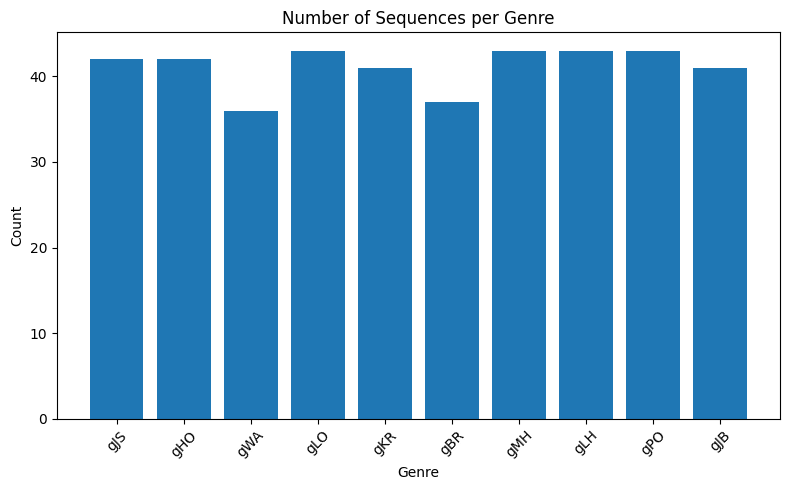

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.xticks(rotation=45)
plt.title("Number of Sequences per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

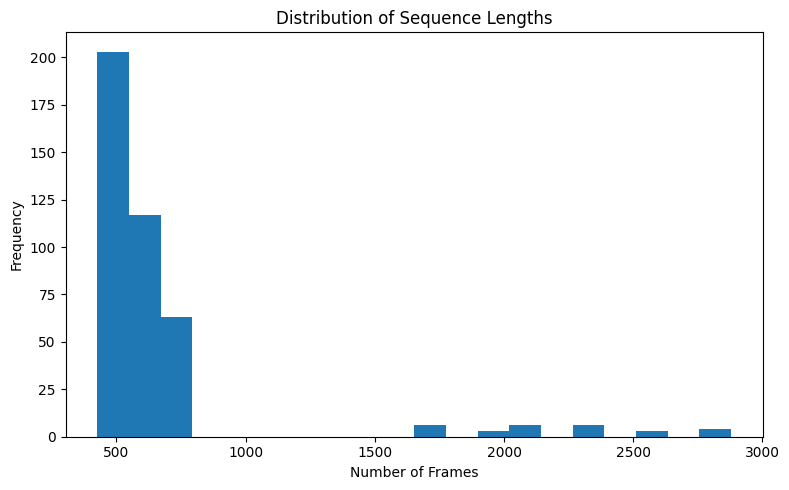

In [7]:
plt.figure(figsize=(8,5))
plt.hist(lengths, bins=20)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Number of Frames")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
with open("ignore_list.txt", "r") as f:
    ignore_set = set(line.strip() for line in f if line.strip())

print("number of ignored sequences:", len(ignore_set))
print("first few ignored:", list(ignore_set)[:5])

number of ignored sequences: 45
first few ignored: ['gWA_sBM_cAll_d26_mWA0_ch09', 'gWA_sBM_cAll_d25_mWA1_ch04', 'gJB_sBM_cAll_d09_mJB4_ch06', 'gWA_sBM_cAll_d27_mWA5_ch01', 'gWA_sBM_cAll_d27_mWA3_ch01']


In [9]:
clean_files = []

for f in files:
    seq_name = f.replace(".pkl", "")
    if seq_name not in ignore_set:
        clean_files.append(f)

print("original file count:", len(files))
print("clean file count:", len(clean_files))

original file count: 411
clean file count: 411


In [10]:
import numpy as np
import pandas as pd

rows = []

for f in clean_files:
    seq_name = f.replace(".pkl", "")
    genre = seq_name.split("_")[0]

    path = os.path.join(motion_dir, f)
    with open(path, "rb") as file:
        d = pickle.load(file)

    smpl_trans = d["smpl_trans"]
    num_frames = d["smpl_poses"].shape[0]

    diffs = np.diff(smpl_trans, axis=0)
    step_sizes = np.linalg.norm(diffs, axis=1)
    mean_motion = step_sizes.mean()
    std_motion = step_sizes.std()

    rows.append({
        "sequence": seq_name,
        "genre": genre,
        "num_frames": num_frames,
        "mean_motion": mean_motion,
        "std_motion": std_motion
    })

df = pd.DataFrame(rows)
df.head()

,sequence,genre,num_frames,mean_motion,std_motion
0,gJS_sBM_cAll_d01_mJS1_ch02,gJS,640,0.130469,0.154842
1,gHO_sBM_cAll_d21_mHO5_ch08,gHO,426,1.323334,0.401874
2,gJS_sBM_cAll_d01_mJS0_ch02,gJS,720,0.124431,0.161430
3,gWA_sBM_cAll_d25_mWA0_ch04,gWA,720,0.654191,0.421162
4,gWA_sBM_cAll_d25_mWA0_ch10,gWA,720,0.943404,0.487555


In [11]:
df.groupby("genre")[["num_frames", "mean_motion", "std_motion"]].mean()

,num_frames,mean_motion,std_motion
genre,,,
gBR,677.027027,1.039569,0.455736
gHO,513.333333,0.972120,0.359795
gJB,641.317073,1.324713,0.620118
gJS,658.833333,0.324037,0.257560
gKR,701.658537,0.763681,0.400468
gLH,627.186047,0.974927,0.459235
gLO,689.627907,0.381465,0.250212
gMH,655.697674,1.161236,0.547987
gPO,731.302326,0.431690,0.270195


In [12]:
import sys
!{sys.executable} -m pip install scipy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 30.3 MB 63.6 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [14]:
from scipy.stats import f_oneway

groups = [group["mean_motion"].values for _, group in df.groupby("genre")]

anova_result = f_oneway(*groups)
print(anova_result)

F_onewayResult(statistic=np.float32(49.589188), pvalue=np.float32(0.0))


In [15]:
matches = []

for f in files:
    seq_name = f.replace(".pkl", "")
    if seq_name in ignore_set:
        matches.append(seq_name)

print("number of matching ignored files:", len(matches))
print(matches[:10])

number of matching ignored files: 0
[]


<Figure size 1000x600 with 0 Axes>

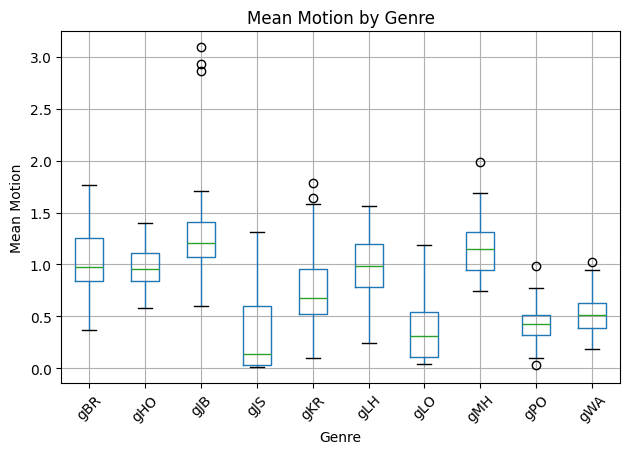

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df.boxplot(column="mean_motion", by="genre")
plt.title("Mean Motion by Genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Mean Motion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

The exploratory analysis showed that the dataset contains 411 motion sequences across 10 dance genres.  
The genre distribution is relatively balanced.  
Motion-based features such as mean motion and motion variability were extracted from `smpl_trans`.  
ANOVA results indicated a statistically significant difference in mean motion across genres, suggesting that movement patterns may help distinguish dance genres.